In [1]:
# ==============================================================================
# DEVELOPERS HUB CORPORATION (DHC)
# Advanced Data Science & Analytics Internship
# TASK 2: Customer Segmentation Using Unsupervised Learning
# Part 1: Environment Initialization
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Unsupervised Machine Learning Frameworks
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

# Enable automatic inline plot rendering inside Colab UI
%matplotlib inline

print("✅ Part 1 Success: Data Science packages and clustering modules initialized successfully.")

✅ Part 1 Success: Data Science packages and clustering modules initialized successfully.


In [2]:
# ==============================================================================
# PART 2: DATASET LOADING
# ==============================================================================
# Note: Ensure 'Mall_Customers.csv' is uploaded to your Colab side panel before running.
try:
    df = pd.read_csv('Mall_Customers.csv')
    print(f"✅ Part 2 Success: Loaded 'Mall_Customers.csv' smoothly.")
    print(f"Data Shape: {df.shape[0]} Rows, {df.shape[1]} Columns.\n")
    print("Initial Data Structure Preview:")
    display(df.head(3))
except FileNotFoundError:
    print("❌ Error: 'Mall_Customers.csv' not found! Please upload the dataset file via the folder icon on the left sidebar.")

✅ Part 2 Success: Loaded 'Mall_Customers.csv' smoothly.
Data Shape: 200 Rows, 5 Columns.

Initial Data Structure Preview:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [3]:
# ==============================================================================
# PART 3: DATA CLEANING AND PREPROCESSING
# ==============================================================================
# 1. Standardize column headers for easier code referencing
df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

# 2. Check for missing values
print("Missing Values Audit:")
print(df.isnull().sum())

# 3. Encode categorical column 'Gender' (Male = 0, Female = 1)
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

# 4. Isolate continuous numeric columns intended for clustering geometric optimization
# We isolate Age, Annual_Income, and Spending_Score
features = ['Age', 'Annual_Income', 'Spending_Score']
X = df[features]

# 5. Feature Scaling (K-Means calculations rely heavily on Euclidean distance metrics)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to clean dataframe layout to preserve metrics tracking
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("\n✅ Part 3 Success: Features scaled and preprocessed smoothly.")

Missing Values Audit:
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

✅ Part 3 Success: Features scaled and preprocessed smoothly.


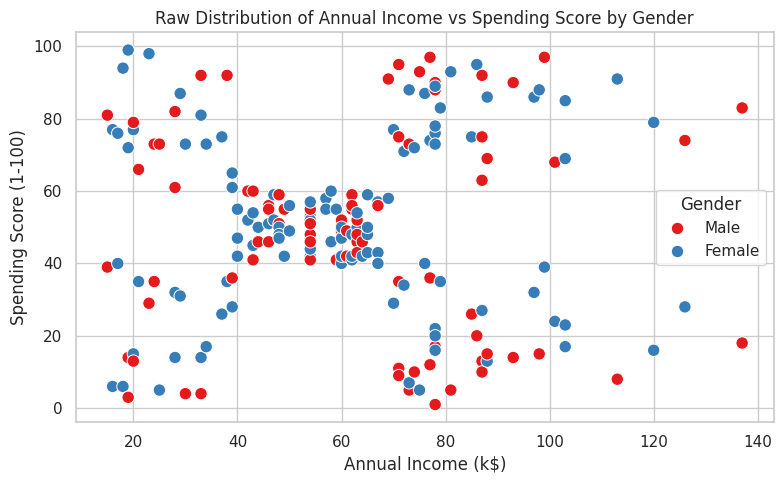

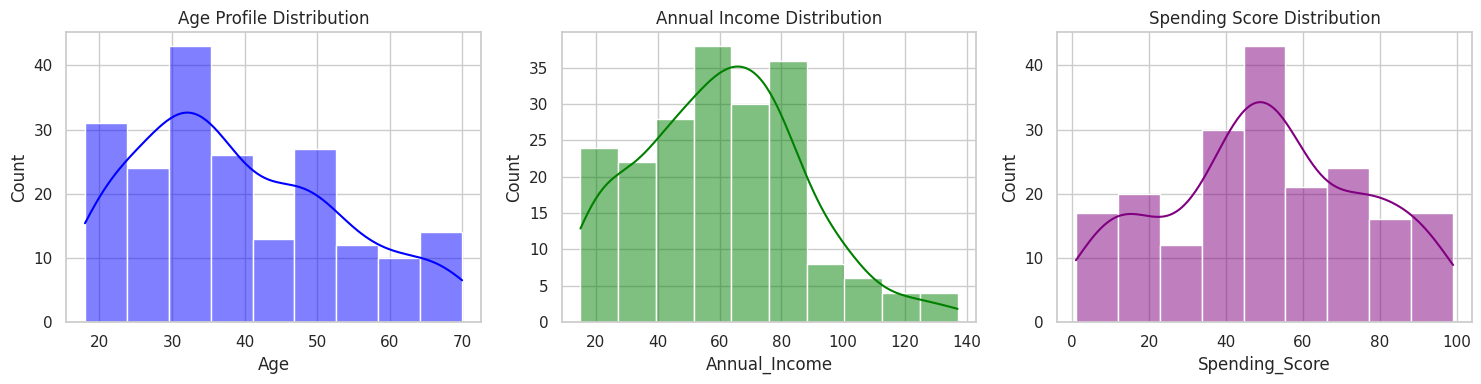

✅ Part 4 Success: EDA plots successfully rendered and stored in the workspace.


In [4]:
# ==============================================================================
# PART 4: EXPLORATORY DATA ANALYSIS (EDA) VISUALIZATIONS
# ==============================================================================
sns.set_theme(style="whitegrid")

# Visualization 1: Joint Kernel Density Distribution Matrix (Income vs Spending)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Gender', palette='Set1', s=80)
plt.title('Raw Distribution of Annual Income vs Spending Score by Gender')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.savefig('eda_income_vs_spending.png', dpi=300)
plt.show()

# Visualization 2: Distribution profiles of numeric variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Age Profile Distribution')

sns.histplot(df['Annual_Income'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending_Score'], kde=True, ax=axes[2], color='purple')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=300)
plt.show()

print("✅ Part 4 Success: EDA plots successfully rendered and stored in the workspace.")

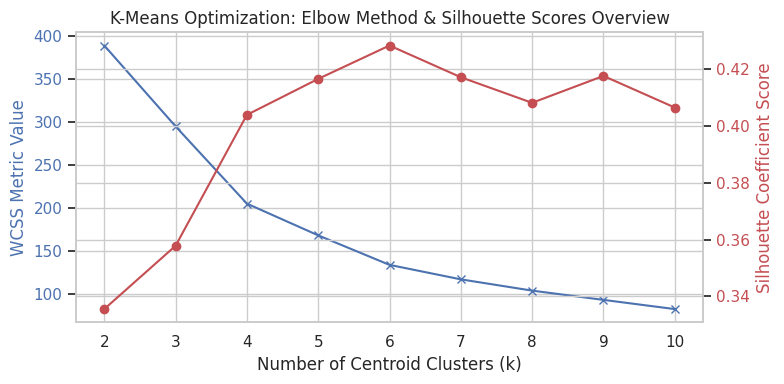

✅ Part 5 Success: Optimal Cluster Allocation Complete. Records mapped into 5 groups.


In [7]:
# ==============================================================================
# PART 5: K-MEANS CLUSTERING CONFIGURATION OPTIMIZATION
# ==============================================================================
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans_model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_model.fit(X_scaled)
    wcss.append(kmeans_model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_model.labels_))

# Plotting the Elbow Curve to find the "Inflection Point"
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(K_range, wcss, 'bx-', label='Within-Cluster Sum of Squares (WCSS)')
ax1.set_xlabel('Number of Centroid Clusters (k)')
ax1.set_ylabel('WCSS Metric Value', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_title('K-Means Optimization: Elbow Method & Silhouette Scores Overview')

# Overlaid line showing silhouette efficiency spikes
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Coefficient Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.grid(True)
plt.tight_layout()
plt.savefig('kmeans_optimization_curves.png', dpi=300)
plt.show()

# Execution Choice based on metrics: 5 Clusters provide optimal segmentation clarity
optimal_k = 5
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster_ID'] = final_kmeans.fit_predict(X_scaled)

print(f"✅ Part 5 Success: Optimal Cluster Allocation Complete. Records mapped into {optimal_k} groups.")

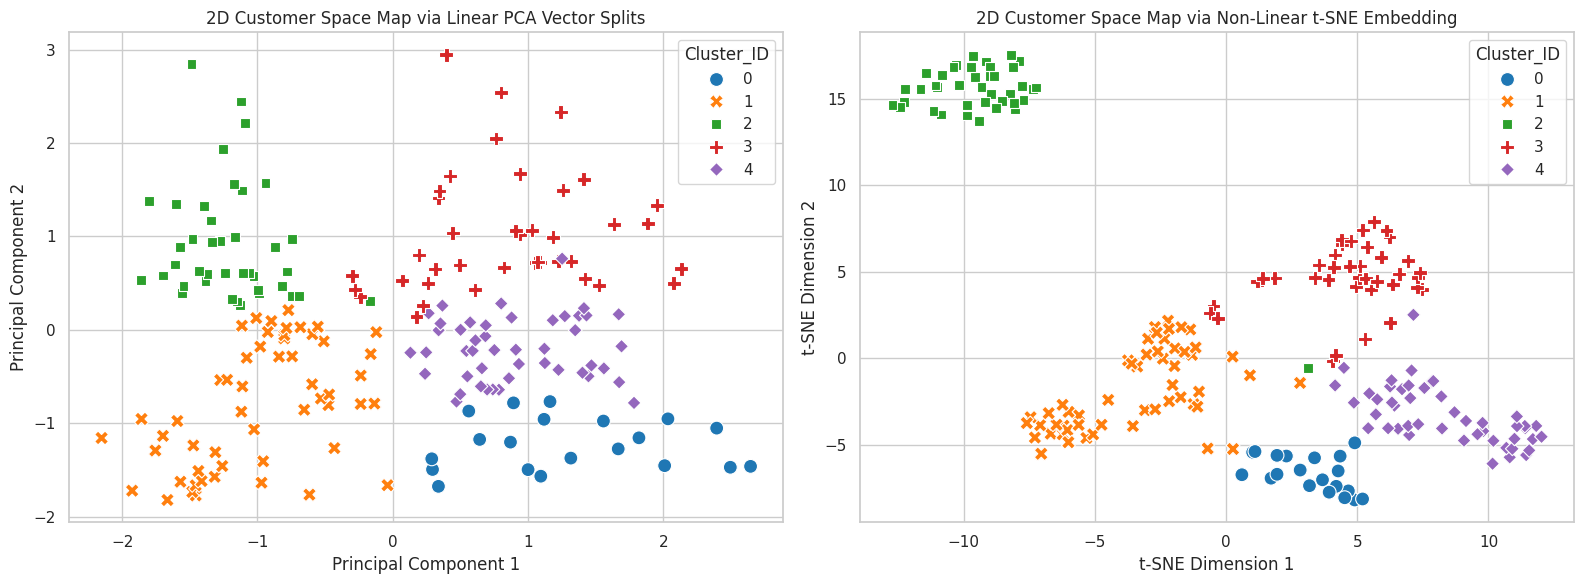


             AGGREGATE STATISTICAL CENTROID VALUES BY SEGMENT


,Age,Annual_Income,Spending_Score
Cluster_ID,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


In [8]:
# ==============================================================================
# PART 6: DIMENSIONALITY REDUCTION & CLUSTER VISUALIZATIONS (PCA & t-SNE)
# ==============================================================================
# 1. Dimensionality Compression using PCA
pca_engine = PCA(n_components=2, random_state=42)
X_pca = pca_engine.fit_transform(X_scaled)
df['PCA_Component_1'] = X_pca[:, 0]
df['PCA_Component_2'] = X_pca[:, 1]

# 2. Dimensionality Compression using non-linear t-SNE
tsne_engine = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne_engine.fit_transform(X_scaled)
df['tSNE_Dimension_1'] = X_tsne[:, 0]
df['tSNE_Dimension_2'] = X_tsne[:, 1]

# Plotting PCA vs t-SNE Spatial Alignments side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='PCA_Component_1', y='PCA_Component_2', hue='Cluster_ID',
                palette='tab10', style='Cluster_ID', s=100, ax=axes[0])
axes[0].set_title('2D Customer Space Map via Linear PCA Vector Splits')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

sns.scatterplot(data=df, x='tSNE_Dimension_1', y='tSNE_Dimension_2', hue='Cluster_ID',
                palette='tab10', style='Cluster_ID', s=100, ax=axes[1])
axes[1].set_title('2D Customer Space Map via Non-Linear t-SNE Embedding')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')

plt.tight_layout()
plt.savefig('cluster_dimensionality_reduction_comparison.png', dpi=300)
plt.show()

# 3. Analyze Profile Aggregation Averages for Strategy Mapping
print("\n" + "="*60)
print("             AGGREGATE STATISTICAL CENTROID VALUES BY SEGMENT")
print("="*60)
analysis_summary = df.groupby('Cluster_ID')[features].mean()
display(analysis_summary)